■ Rotated Object Detection
  - to use Oriented R-CNN pretrained on DOTA.
  - to train a MMRotate detector with SSDD.
  - to perform inference.



- Display SSDD (SAR Ship Detection Dataset) and OBB
  - original SSDD : HBB, OBB, semgmentation points 
  - https://github.com/TianwenZhang0825/Official-SSDD

d:\Project-MMRotate\venv_py39\lib\site-packages\mmcv\__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


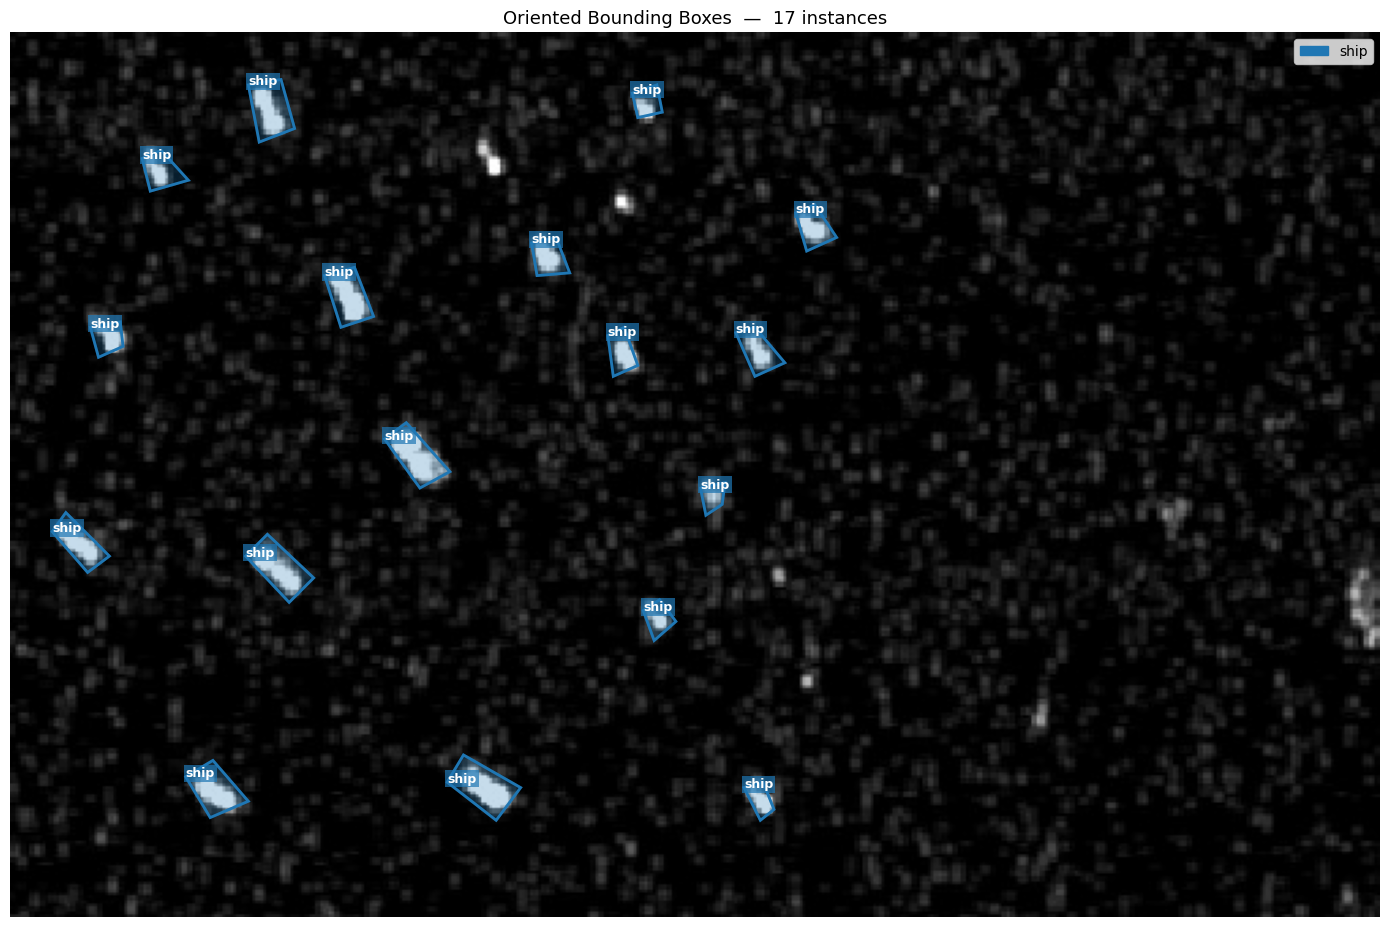

In [1]:
import mmcv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors

#-----------------------------------------------------------------------
# When mmrotate (>1.0.0rc) installed for RotLocalVisualizer
# from mmrotate.visualization import RotLocalVisualizer
#-----------------------------------------------------------------------
# Mult-Color Oriented BBox using matplotlib Polygon patches
def draw_obb(ax, bboxes, labels, colors=None, linewidth=2, alpha=0.8, show_label=True):
    """
    Draw oriented bounding boxes on a matplotlib Axes.
    Args:
        ax: matplotlib Axes object
        bboxes: np.ndarray of shape (N, 8) — [x1,y1, x2,y2, x3,y3, x4,y4]
        labels: list of str, length N
        colors: list of colors (optional); cycles through defaults if None
        linewidth: edge line width
        alpha: fill alpha
        show_label: whether to annotate class name at first corner
    """
    default_colors = list(mcolors.TABLEAU_COLORS.values())
    unique_classes = list(set(labels))
    class_color = {  cls: default_colors[i % len(default_colors)]
                        for i, cls in enumerate(unique_classes) }

    for i, (bbox, label) in enumerate(zip(bboxes, labels)):
        # Reshape flat [x1,y1,...,x4,y4] → (4,2) polygon vertices
        pts = bbox.reshape(4, 2)
        color = class_color[label]
        poly = Polygon(pts, closed=True, edgecolor=color, 
                       facecolor=color, linewidth=linewidth, alpha=0.25)
        ax.add_patch(poly)
        # Draw edge outline separately (full opacity)
        outline = Polygon(pts, closed=True, edgecolor=color, 
                          facecolor='none', linewidth=linewidth)
        ax.add_patch(outline)

        if show_label:
            # Place label near the first vertex (top-left-ish)
            ax.text(pts[0, 0], pts[0, 1],
                    label,
                    color='white',
                    fontsize=9,
                    fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.7,
                              edgecolor='none', pad=1.5))
    return class_color

# 1. Load image & label txt 
# img = mmcv.imread('image.jpg', channel_order='rgb')
img_path = 'D:/Project-Datasets/ssdd_tiny/images/000739.png'
label_path = 'D:/Project-Datasets/ssdd_tiny/val/000739.txt'
img = mmcv.imread(img_path)  # ssdd is gray-scale

# 2. Parse 000739.txt 
# format: x1 y1 x2 y2 x3 y4 x4 y4 class_name difficulty
labels = []
bboxes = []
with open( label_path, 'r') as f:
    for line in f.readlines():
        parts = line.strip().split()
        # Take first 8 as coordinates, last as class
        coords = [float(x) for x in parts[:8]]
        bboxes.append(coords)
        labels.append(parts[8]) # Simplified class handling

# Convert to tensor/numpy
bboxes = np.array(bboxes, dtype=np.float32)
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.imshow(mmcv.bgr2rgb(img))
class_color = draw_obb(ax, bboxes, labels, linewidth=2, alpha=0.25, show_label=True)
# Legend
legend_handles = [ patches.Patch(facecolor=color, edgecolor=color, label=cls)
                    for cls, color in class_color.items() ]
ax.legend(handles=legend_handles, loc='upper right',
          fontsize=10, framealpha=0.8)
ax.set_title(f'Oriented Bounding Boxes  —  {len(bboxes)} instances', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

- Take a peek at the label txt file 000739.txt : OBB, class name, difficulty
  
  => format: x1 y1 x2 y2 x3 y4 x4 y4 class_name difficulty

In [2]:
with open(label_path, 'r', encoding='utf-8') as f:
    print(f.read())

269 277 275 289 280 285 276 275 ship 0
160 275 178 289 187 277 166 265 ship 0
64 273 73 288 87 282 74 267 ship 0
232 212 236 223 244 216 238 208 ship 0
86 192 102 209 111 200 94 184 ship 0
15 183 28 198 36 192 20 176 ship 0
137 149 150 167 161 161 145 143 ship 0
219 111 221 126 230 122 225 108 ship 0
266 110 273 126 284 121 273 108 ship 0
115 89 121 108 133 104 126 86 ship 0
191 77 193 89 205 88 200 75 ship 0
288 66 292 80 303 75 295 63 ship 0
253 167 255 177 261 173 262 165 ship 0
228 22 230 31 239 29 237 19 ship 0
87 19 91 40 104 35 99 17 ship 0
48 46 51 58 65 54 55 43 ship 0
29 108 32 119 41 115 40 106 ship 0



- Register the custom dataset class & Early Stopping setup

In [3]:
from mmrotate.datasets.builder import ROTATED_DATASETS
from mmrotate.datasets.dota import DOTADataset
from mmcv.runner import HOOKS, Hook

@ROTATED_DATASETS.register_module()
class TinySSDDataset(DOTADataset):
    """SAR ship dataset for detection."""
    CLASSES = ('ship',)

@HOOKS.register_module()
class EarlyStoppingHook(Hook):
    def __init__(self, monitor='mAP', patience=5, min_delta=0.001, rule='greater'):
        self.monitor = monitor
        self.patience = patience
        self.min_delta = min_delta
        self.rule = rule
        self.best_score = None
        self.counter = 0

    def after_val_epoch(self, runner):
        current_score = runner.log_buffer.output.get(self.monitor, None)
        if current_score is None:
            return

        if self.best_score is None:
            self.best_score = current_score
            return

        if self.rule == 'greater':
            improved = current_score > self.best_score + self.min_delta
        else:
            improved = current_score < self.best_score - self.min_delta

        if improved:
            self.best_score = current_score
            self.counter = 0
            runner.logger.info(f'EarlyStopping: {self.monitor} improved to {self.best_score:.4f}')
        else:
            self.counter += 1
            runner.logger.info(f'EarlyStopping: no improvement ({self.counter}/{self.patience})')
            if self.counter >= self.patience:
                runner.logger.info('EarlyStopping: stopping training')
                runner.should_stop = True  # 학습 중단 플래그


- Modifcation of Configuartions for Model, Dataset, Training 

1. The ResNet-50 backbone pre-trained on ImageNet is loaded : all the weights of the ResNet-50 backbone are loaded except the conv1.bias, which has been merged into conv.weights.

2. Oriented R-CNN model loaded to finetune it for detection. The original Oriented R-CNN is trained on DOTA dataset which contains 15 classes but SSDD dataset only have 1 classes. Therefore, the last FC layer of the pre-trained Oriented R-CNN for classification has different weight shape and is not used.

3. The detector is evaluated by the default evaluation. The results show that the detector achieves around 90 mAP on the val dataset.

In [4]:
from mmrotate.models import build_detector
from mmcv import Config
from mmdet.apis import set_random_seed

config_path = 'D:/Project-MMRotate/mmrotate/configs/oriented_rcnn/oriented_rcnn_r50_fpn_1x_dota_le90.py'
config = Config.fromfile(config_path)
model = build_detector(config.model)

# Modify dataset type and path
config.dataset_type = 'TinySSDDataset'
config.data_root = 'D:/Project-Datasets/ssdd_tiny/'

config.data.test.type = 'TinySSDDataset'
config.data.test.data_root = 'D:/Project-Datasets/ssdd_tiny/'
config.data.test.ann_file = 'val'
config.data.test.img_prefix = 'images'

config.data.train.type = 'TinySSDDataset'
config.data.train.data_root = 'D:/Project-Datasets/ssdd_tiny/'
config.data.train.ann_file = 'train'
config.data.train.img_prefix = 'images'

config.data.val.type = 'TinySSDDataset'
config.data.val.data_root = 'D:/Project-Datasets/ssdd_tiny/'
config.data.val.ann_file = 'val'
config.data.val.img_prefix = 'images'

# 0으로 설정 (멀티프로세싱 비활성화) 
# num_workers=0이면 반드시 False
config.data.workers_per_gpu = 0

# Modify num classes of the model in box head
config.model.roi_head.bbox_head.num_classes = 1
# Use the pre-trained Mask RCNN model 
# though we do not need to use the mask branch
config.load_from = 'oriented_rcnn_r50_fpn_1x_dota_le90-6d2b2ce0.pth'
# Set up working dir to save files and logs.
config.work_dir = 'work_dirs/oriented_rcnn_r50_fpn_1x_SSDD_Sample_le90'

config.optimizer.lr = 0.001
config.lr_config.warmup = None
config.runner.max_epochs = 30
config.log_config.interval = 10

# Change the evaluation metric.
config.evaluation.metric = 'mAP'
# Set the evaluation interval to reduce the evaluation times
config.evaluation.interval = 3
# Set the checkpoint saving interval 
config.checkpoint_config.interval = 3
# Best checkpoint 저장은 evaluation에 옵션
config.evaluation.save_best = 'mAP'  # 'mAP' 기준으로 best.pth 저장
config.custom_hooks = [ dict(
        type='EarlyStoppingHook',
        monitor='mAP',
        patience=5,
        min_delta=0.001,
        rule='greater'
        )
    ]

# Set seed thus the results are more reproducible
config.seed = 0
set_random_seed(0, deterministic=False)
config.gpu_ids = range(1)  # 1 GPU type = range
config.device='cuda'

# We can also use tensorboard to log the training process
config.log_config.hooks = [
    dict(type='TextLoggerHook'),
    dict(type='TensorboardLoggerHook')]

# Initialize the logger for training & 
# Take a look at the final config used for training
print(f'Config:\n{config.pretty_text}')

d:\Project-MMRotate\venv_py39\lib\site-packages\mmdet\models\dense_heads\anchor_head.py:116: UserWarning: DeprecationWarning: `num_anchors` is deprecated, for consistency or also use `num_base_priors` instead
  warnings.warn('DeprecationWarning: `num_anchors` is deprecated, '


Config:
dataset_type = 'TinySSDDataset'
data_root = 'D:/Project-Datasets/ssdd_tiny/'
img_norm_cfg = dict(
    mean=[123.675, 116.28, 103.53], std=[58.395, 57.12, 57.375], to_rgb=True)
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations', with_bbox=True),
    dict(type='RResize', img_scale=(1024, 1024)),
    dict(
        type='RRandomFlip',
        flip_ratio=[0.25, 0.25, 0.25],
        direction=['horizontal', 'vertical', 'diagonal'],
        version='le90'),
    dict(
        type='Normalize',
        mean=[123.675, 116.28, 103.53],
        std=[58.395, 57.12, 57.375],
        to_rgb=True),
    dict(type='Pad', size_divisor=32),
    dict(type='DefaultFormatBundle'),
    dict(type='Collect', keys=['img', 'gt_bboxes', 'gt_labels'])
]
test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(
        type='MultiScaleFlipAug',
        img_scale=(1024, 1024),
        flip=False,
        transforms=[
            dict(type='RResize'),
            dict(

In [5]:
import os.path as osp
from mmdet.datasets import build_dataset
from mmdet.models import build_detector
from mmdet.apis import train_detector
import mmcv
# Build dataset
datasets = [build_dataset(config.data.train)]

# Build the detector
model = build_detector( config.model, train_cfg=config.get('train_cfg'), 
                        test_cfg=config.get('test_cfg'))
# Add an attribute for visualization convenience
model.CLASSES = datasets[0].CLASSES

# Create work_dir
mmcv.mkdir_or_exist(osp.abspath(config.work_dir))
train_detector(model, datasets, config, distributed=False, validate=True)

2026-03-12 02:24:01,970 - mmdet - INFO - Automatic scaling of learning rate (LR) has been disabled.
2026-03-12 02:24:02,002 - mmdet - INFO - load checkpoint from local path: oriented_rcnn_r50_fpn_1x_dota_le90-6d2b2ce0.pth
2026-03-12 02:24:02,132 - mmdet - WARNING - The model and loaded state dict do not match exactly

size mismatch for roi_head.bbox_head.fc_cls.weight: copying a param with shape torch.Size([16, 1024]) from checkpoint, the shape in current model is torch.Size([2, 1024]).
size mismatch for roi_head.bbox_head.fc_cls.bias: copying a param with shape torch.Size([16]) from checkpoint, the shape in current model is torch.Size([2]).
2026-03-12 02:24:02,145 - mmdet - INFO - Start running, host: 82106@kscha92, work_dir: d:\Project-MMRotate\work_dirs\oriented_rcnn_r50_fpn_1x_SSDD_Sample_le90
2026-03-12 02:24:02,146 - mmdet - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) StepLrUpdaterHook                  
(NORMAL      ) CheckpointHook           

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 84/84, 7.4 task/s, elapsed: 11s, ETA:     0s

2026-03-12 02:25:37,203 - mmdet - INFO - 
+-------+-----+------+--------+-------+
| class | gts | dets | recall | ap    |
+-------+-----+------+--------+-------+
| ship  | 176 | 2856 | 0.943  | 0.886 |
+-------+-----+------+--------+-------+
| mAP   |     |      |        | 0.886 |
+-------+-----+------+--------+-------+
2026-03-12 02:25:38,475 - mmdet - INFO - Now best checkpoint is saved as best_mAP_epoch_3.pth.
2026-03-12 02:25:38,477 - mmdet - INFO - Best mAP is 0.8862 at 3 epoch.
2026-03-12 02:25:38,477 - mmdet - INFO - Epoch(val) [3][84]	mAP: 0.8862
2026-03-12 02:25:44,584 - mmdet - INFO - Epoch [4][10/55]	lr: 1.000e-03, eta: 0:10:42, time: 0.609, data_time: 0.247, memory: 3614, loss_rpn_cls: 0.0017, loss_rpn_bbox: 0.0102, loss_cls: 0.0906, acc: 97.8027, loss_bbox: 0.0986, loss: 0.2010, grad_norm: 1.5570
2026-03-12 02:25:48,640 - mmdet - INFO - Epoch [4][20/55]	lr: 1.000e-03, eta: 0:10:36, time: 0.406, data_time: 0.049, memory: 3614, loss_rpn_cls: 0.0035, loss_rpn_bbox: 0.0170, lo

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 84/84, 8.7 task/s, elapsed: 10s, ETA:     0s

2026-03-12 02:27:07,645 - mmdet - INFO - 
+-------+-----+------+--------+-------+
| class | gts | dets | recall | ap    |
+-------+-----+------+--------+-------+
| ship  | 176 | 2386 | 0.955  | 0.891 |
+-------+-----+------+--------+-------+
| mAP   |     |      |        | 0.891 |
+-------+-----+------+--------+-------+
2026-03-12 02:27:07,720 - mmdet - INFO - The previous best checkpoint d:\Project-MMRotate\work_dirs\oriented_rcnn_r50_fpn_1x_SSDD_Sample_le90\best_mAP_epoch_3.pth was removed
2026-03-12 02:27:08,951 - mmdet - INFO - Now best checkpoint is saved as best_mAP_epoch_6.pth.
2026-03-12 02:27:08,952 - mmdet - INFO - Best mAP is 0.8905 at 6 epoch.
2026-03-12 02:27:08,952 - mmdet - INFO - Epoch(val) [6][84]	mAP: 0.8905
2026-03-12 02:27:15,303 - mmdet - INFO - Epoch [7][10/55]	lr: 1.000e-03, eta: 0:09:07, time: 0.633, data_time: 0.247, memory: 3614, loss_rpn_cls: 0.0023, loss_rpn_bbox: 0.0142, loss_cls: 0.0708, acc: 97.5488, loss_bbox: 0.1051, loss: 0.1924, grad_norm: 1.9494
2026

...

2026-03-12 02:36:26,414 - mmdet - INFO - 
+-------+-----+------+--------+-------+
| class | gts | dets | recall | ap    |
+-------+-----+------+--------+-------+
| ship  | 176 | 2325 | 0.949  | 0.892 |
+-------+-----+------+--------+-------+
| mAP   |     |      |        | 0.892 |
+-------+-----+------+--------+-------+
2026-03-12 02:36:26,468 - mmdet - INFO - Epoch(val) [24][84]	mAP: 0.8923
2026-03-12 02:36:32,520 - mmdet - INFO - Epoch [25][10/55]	lr: 1.000e-05, eta: 0:02:12, time: 0.603, data_time: 0.247, memory: 3614, loss_rpn_cls: 0.0005, loss_rpn_bbox: 0.0151, loss_cls: 0.0717, acc: 97.1875, loss_bbox: 0.1017, loss: 0.1890, grad_norm: 2.0139
2026-03-12 02:36:36,538 - mmdet - INFO - Epoch [25][20/55]	lr: 1.000e-05, eta: 0:02:08, time: 0.402, data_time: 0.052, memory: 3614, loss_rpn_cls: 0.0008, loss_rpn_bbox: 0.0241, loss_cls: 0.0738, acc: 97.1680, loss_bbox: 0.1370, loss: 0.2358, grad_norm: 2.0595
2026-03-12 02:36:40,710 - mmdet - INFO - Epoch [25][30/55]	lr: 1.000e-05, eta: 0:02

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 84/84, 8.3 task/s, elapsed: 10s, ETA:     0s

2026-03-12 02:38:00,731 - mmdet - INFO - 
+-------+-----+------+--------+-------+
| class | gts | dets | recall | ap    |
+-------+-----+------+--------+-------+
| ship  | 176 | 2320 | 0.955  | 0.892 |
+-------+-----+------+--------+-------+
| mAP   |     |      |        | 0.892 |
+-------+-----+------+--------+-------+
2026-03-12 02:38:00,808 - mmdet - INFO - The previous best checkpoint d:\Project-MMRotate\work_dirs\oriented_rcnn_r50_fpn_1x_SSDD_Sample_le90\best_mAP_epoch_21.pth was removed
2026-03-12 02:38:02,100 - mmdet - INFO - Now best checkpoint is saved as best_mAP_epoch_27.pth.
2026-03-12 02:38:02,101 - mmdet - INFO - Best mAP is 0.8924 at 27 epoch.
2026-03-12 02:38:02,102 - mmdet - INFO - Epoch(val) [27][84]	mAP: 0.8924
2026-03-12 02:38:08,606 - mmdet - INFO - Epoch [28][10/55]	lr: 1.000e-05, eta: 0:01:04, time: 0.649, data_time: 0.247, memory: 3614, loss_rpn_cls: 0.0008, loss_rpn_bbox: 0.0101, loss_cls: 0.0609, acc: 97.8320, loss_bbox: 0.0944, loss: 0.1662, grad_norm: 1.8989

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 84/84, 8.2 task/s, elapsed: 10s, ETA:     0s

2026-03-12 02:39:36,846 - mmdet - INFO - 
+-------+-----+------+--------+-------+
| class | gts | dets | recall | ap    |
+-------+-----+------+--------+-------+
| ship  | 176 | 2319 | 0.960  | 0.891 |
+-------+-----+------+--------+-------+
| mAP   |     |      |        | 0.891 |
+-------+-----+------+--------+-------+
2026-03-12 02:39:36,898 - mmdet - INFO - Epoch(val) [30][84]	mAP: 0.8908


- Test the trained detector :

    Visualizing the prediction results after finetuning the detector

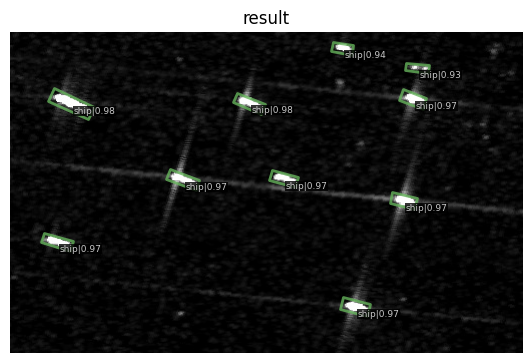

In [6]:
from mmdet.apis import inference_detector, show_result_pyplot
infer_img_path = 'D:/Project-Datasets/ssdd_tiny/images/001129.png'
img = mmcv.imread(infer_img_path)
model.cfg = config
result = inference_detector(model, img)
show_result_pyplot(model, img, result, score_thr=0.3)